In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax.random import key, split, uniform

from astro import seconds_per_day
from astro import days_per_year
from astro import period_min, period_max
from astro import mprog_min, mprog_max, mprog_break


from astro import calc_orbital_seperation

from astro import calc_beta
from astro import calc_cos_theta
from astro import calc_relative_semimajoraxis
from astro import calc_orbital_velocity

from astro import calc_spin_orbit_misalignment
from astro import draw_kick_and_compute_new_orbit
from astro import calc_orbital_decay_time

from astro import draw_maxwellian_velocity

%load_ext autoreload
%autoreload 2

/n/home03/newolfe/.conda/envs/seqpop/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def calc_spin_orbit_misalignment(gamma, theta_star, phi_star):
    cos_tau = jnp.sin(theta_star) * jnp.sin(phi_star) * jnp.sin(gamma)
    cos_tau += jnp.cos(theta_star) * jnp.cos(gamma)
    return cos_tau

In [3]:
from models import build_interp_sampler
from astro import log_bpl_progenitor_mass
from astro import sample_mbh_given_mprog_golomb2023

def sample_progenitor_masses(key, parameters):
    ms = jnp.linspace(
        mprog_min,
        mprog_max,
        500
    )

    sample_mprog = build_interp_sampler(
        lambda x: jnp.exp(log_bpl_progenitor_mass(
            x,
            parameters['alpha_prog_1'],
            parameters['alpha_prog_2'],
            mprog_min,
            mprog_max,
            mprog_break,
        )),
        ms
    )

    # sample mprog
    key, subkey = split(key)
    mprog1 = sample_mprog(subkey)

    key, subkey = split(key)
    mprog2 = sample_mprog(subkey)

    return mprog1, mprog2


def sample_bh_masses(key, mprog1, mprog2, parameters):
    key, subkey = split(key)
    mbh1 = sample_mbh_given_mprog_golomb2023(
        subkey,
        mprog1,
        parameters['mbhmax'],
        parameters['mturnover'],
        parameters['sigma_mbh']
    )


    key, subkey = split(key)
    mbh2 = sample_mbh_given_mprog_golomb2023(
        subkey,
        mprog2,
        parameters['mbhmax'],
        parameters['mturnover'],
        parameters['sigma_mbh']
    )

    return mbh1, mbh2

In [4]:
from astro import au_per_meter

def get_binary(key, parameters):
    # masses
    key, subkey = split(key)
    mprog_a, mprog_b = sample_progenitor_masses(subkey, parameters)

    key, subkey = split(key)
    mbh_a, mbh_b = sample_bh_masses(subkey, mprog_a, mprog_b, parameters) 

    mtot_0 = mprog_a + mprog_b
    mtot_1 = mbh_a + mprog_b
    mtot_2 = mbh_a + mbh_b

    beta_1 = calc_beta(mtot_0, mtot_1)
    beta_2 = calc_beta(mtot_1, mtot_2)

    # initial angles
    # TODO: come in here with a crude "triple" prescription?
    cos_theta_a_0 = 1.0
    cos_theta_b_0 = 1.0

    key, subkey = split(key)
    phi_a, phi_b = uniform(subkey, (2,), minval=0, maxval=2 * jnp.pi) 

    # initial orbital properties
    key, subkey = split(key)
    log_period_days = jax.random.uniform(
        subkey,
        minval=jnp.log(period_min),
        maxval=jnp.log(period_max)
    )  # [days]
    a0 = calc_orbital_seperation(jnp.exp(log_period_days), mtot_0)  # [ AU ]
    vorb_0 = calc_orbital_velocity(mtot_0, a0)  # [ km / s ]

    # blow up the first star and kick it!
    # note: cos_gamma_1 relates to ANGLE BETWEEN PRE-SN1 and POST-SN1 FRAME
    key, subkey = split(key)
    (
        v_kick_1, # [ km / s ]
        u_kick_1,
        alpha_1,
        ecc_1,
        cos_gamma_1
    ) = draw_kick_and_compute_new_orbit(
        subkey,
        beta_1,
        vorb_0,
        parameters['sigma_kick']
    )
    gamma_1 = jnp.arccos(cos_gamma_1)

    cos_theta_a_1 = calc_spin_orbit_misalignment(
        gamma_1, jnp.arccos(cos_theta_a_0), phi_a
    )
    cos_theta_b_1 = calc_spin_orbit_misalignment(
        gamma_1, jnp.arccos(cos_theta_b_0), phi_b
    )

    a1 = alpha_1 * a0
    vorb_1 = calc_orbital_velocity(mtot_1, a1)

    # blow up the second start and kick it!
    # note: cos_gamma_2 relates to ANGLE BETWEEN PRE-SN2 and POST-SN2 FRAME
    # and v_kick_2 is drawn in the PRE-SN2 FRAME
    key, subkey = split(key)
    (
        v_kick_2,
        u_kick_2,
        alpha_2,
        ecc_2,
        cos_gamma_2
    ) = draw_kick_and_compute_new_orbit(
        subkey,
        beta_2,
        vorb_1,
        parameters['sigma_kick']
    )
    gamma_2 = jnp.arccos(cos_gamma_2)

    cos_theta_a_2 = calc_spin_orbit_misalignment(
        gamma_2, jnp.arccos(cos_theta_a_1), phi_a
    )
    cos_theta_b_2 = calc_spin_orbit_misalignment(
        gamma_2, jnp.arccos(cos_theta_b_1), phi_b
    )

    a2 = alpha_2 * a1
    vorb_2 = calc_orbital_velocity(mtot_2, a2)

    survive = (alpha_2 > 0) & (ecc_2 < 1) & (mbh_b > 0)

    decay_time = calc_orbital_decay_time(a2 / au_per_meter, mbh_a, mbh_b) # [ seconds ]
    log_decay_time = jnp.log(decay_time) - jnp.log(seconds_per_day) - jnp.log(days_per_year)
    merge = log_decay_time < jnp.log(14e9)
    
    # TODO: ugly!
    return dict(
        mprog_a=mprog_a,
        mprog_b=mprog_b,
        mbh_a=mbh_a,
        mbh_b=mbh_b,
        mtot_0=mtot_0,
        mtot_1=mtot_1,
        mtot_2=mtot_2,
        beta_1=beta_1,
        beta_2=beta_2,
        log_period=log_period_days,
        alpha_1=alpha_1,
        alpha_2=alpha_2,
        a0=a0,
        a1=a1,
        a2=a2,
        vorb_0=vorb_0,
        vorb_1=vorb_1,
        vorb_2=vorb_2,
        v_kick_1=v_kick_1,
        v_kick_2=v_kick_2,
        u_kick_1=u_kick_1,
        u_kick_2=u_kick_2,
        ecc_1=ecc_1,
        ecc_2=ecc_2,
        cos_gamma_1=cos_gamma_1,
        cos_gamma_2=cos_gamma_1,
        cos_theta_a_1=cos_theta_a_1,
        cos_theta_a_2=cos_theta_a_2,
        cos_theta_b_1=cos_theta_b_1,
        cos_theta_b_2=cos_theta_b_2,
        phi_a=phi_a,
        phi_b=phi_b,
        log_decay_time=log_decay_time,
        survive=survive,
        merge=merge,
    )

In [5]:
@jax.jit
def get_pop(sigma_kick, n=1_000_000):
    """ sigma_kick in km / s """
    parameters = dict(
        mbhmax=45,
        mturnover=35,
        sigma_mbh=0,
        alpha_prog_1=2.0,
        alpha_prog_2=1.1,
        sigma_kick=sigma_kick
    )

    return jax.vmap(
        lambda k: get_binary(k, parameters)
    )(split(key(1), n))

In [6]:
from jax_tqdm import scan_tqdm

nsigma = 50
sigmas = jnp.logspace(1, 4, nsigma)

@scan_tqdm(nsigma, desc='Generating populations')
def step(carry, x):
    _, sigma = x
    return carry, get_pop(sigma)

_, pops = jax.lax.scan(step, None, (jnp.arange(nsigma), sigmas))

Generating populations: 100%|██████████| 50/50 [00:00<00:00, 301.09it/s]


Beyond a dispersion velocity of a few thousand, basically no binaries survive!

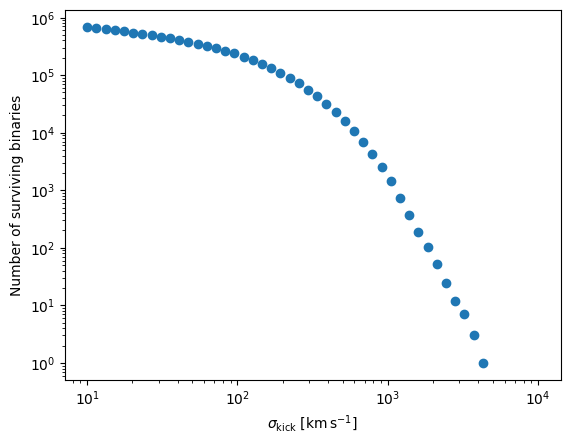

In [8]:
fig, ax = plt.subplots()
ax.scatter(
    sigmas,
    jnp.sum(pops['survive'], axis=-1),
)
ax.loglog();
ax.set_ylabel('Number of surviving binaries')
ax.set_xlabel(r'$\sigma_{\rm kick}$ [$\mathrm{km} \, \mathrm{s}^{-1}$]')
fig.savefig('../../notes/figures/25-12-18/survival.png')

In [9]:
from jax_tqdm import scan_tqdm

nsigma = 10
sigmas = jnp.logspace(1, 3, nsigma)

@scan_tqdm(nsigma, desc='Generating populations')
def step(carry, x):
    _, sigma = x
    return carry, get_pop(sigma)

_, pops = jax.lax.scan(step, None, (jnp.arange(nsigma), sigmas))

Generating populations: 100%|██████████| 10/10 [00:00<00:00, 312.60it/s]


In [10]:
from arviz import hdi
import numpy as np

ci90s = []

for i in range(nsigma):
    mask = pops['survive'][i] & pops['merge'][i]
    ct = np.array(pops['cos_theta_a_2'][i][mask])
    ci90s.append(hdi(ct, hdi_prob=0.9))

ci90s = np.array(ci90s)

ci99s = []

for i in range(nsigma):
    mask = pops['survive'][i] & pops['merge'][i]
    ct = np.array(pops['cos_theta_a_2'][i][mask])
    ci99s.append(hdi(ct, hdi_prob=0.99))

ci99s = np.array(ci99s)

ci50s = []

for i in range(nsigma):
    mask = pops['survive'][i] & pops['merge'][i]
    ct = np.array(pops['cos_theta_a_2'][i][mask])
    ci50s.append(hdi(ct, hdi_prob=0.5))

ci50s = np.array(ci50s)

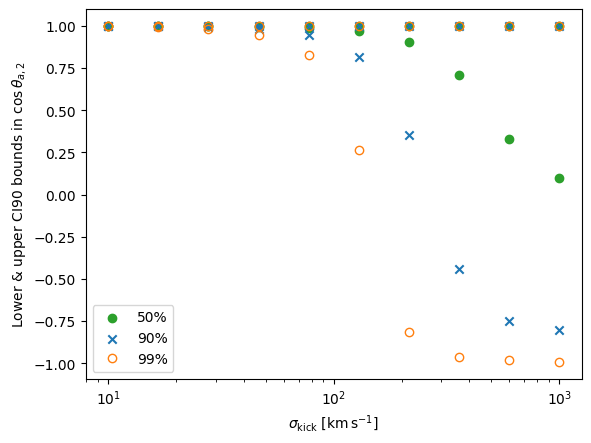

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(sigmas, ci50s[:, 0], color='C2', label='50%')
ax.scatter(sigmas, ci50s[:, 1], color='C2')

ax.scatter(sigmas, ci90s[:, 0], color='C0', marker='x', label='90%')
ax.scatter(sigmas, ci90s[:, 1], color='C0', marker='x')

ax.plot(sigmas, ci99s[:, 0], linestyle='', markeredgecolor='C1', marker='o', markerfacecolor='none', label='99%')
ax.plot(sigmas, ci99s[:, 1], linestyle='', markeredgecolor='C1', marker='o', markerfacecolor='none')

ax.set_xscale('log')

ax.set_xlabel(r'$\sigma_{\rm kick}$ [$\mathrm{km} \, \mathrm{s}^{-1}$]')

ax.set_ylabel(r'Lower & upper CI90 bounds in $\cos \theta_{a, 2}$')

ax.legend()

fig.savefig('../../notes/figures/25-12-18/two-star-tilt-ci90s.png')

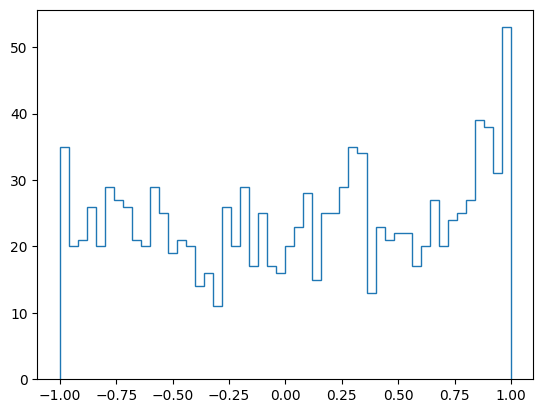

In [13]:
fig, ax = plt.subplots()
mask = pops['survive'][-1] & pops['merge'][-1]
ax.hist(pops['cos_theta_a_2'][-1][mask], histtype='step', bins=50);

In [ ]:
import precession.eccentricity as precession

from astro import speed_of_light
from astro import au_per_meter
from astro import kg_per_msun

grav_constant_si = 6.67e-11

In [ ]:
from astro import speed_of_light
from astro import au_per_meter
from astro import kg_per_msun

grav_constant_si = 6.67e-11

index = 273

a_end_evol = pops['a2'][-1][index] / au_per_meter
mtot_end_evol = pops['mtot_2'][-1][index] * kg_per_msun 
a_end_evol_geom = a_end_evol * mtot_end_evol * grav_constant_si / speed_of_light**2

ecc_end_evol = pops['ecc_2'][-1][index]

q_end_evol = pops['mbh_a'][-1][index] / pops['mbh_b'][-1][index]

if q_end_evol > 1:
    q_end_evol = 1 / q_end_evol

In [109]:
a_array = np.logspace(
    4, #np.log10(a_end_evol),
    1,
    1_000
)

In [110]:
chi1 = 0.2 #np.random.uniform(0, 0.2)
chi2 = 0.1 #np.random.uniform(0, 0.2)
#theta1, theta2, deltaphi = precession.isotropic_angles(N=1)

# b/c I know which component is heavier here...
theta1 = jnp.arccos(pops['cos_theta_b_2'][-1][index])
theta2 = jnp.arccos(pops['cos_theta_a_2'][-1][index])

deltaphi = pops['phi_b'][-1][index] - pops['phi_a'][-1][index]

In [111]:
out = precession.inspiral_precav(theta1=theta1,theta2=theta2,deltaphi=deltaphi,a=a_array,e=ecc_end_evol,q=q_end_evol,chi1=chi1,chi2=chi2)

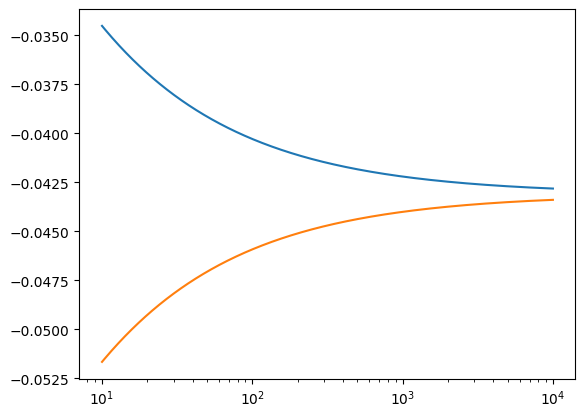

In [112]:
fig, ax = plt.subplots()

ax.plot(
    out['a'].squeeze(), #a_array,
    out['deltachiplus'].squeeze()
)
ax.plot(
    out['a'].squeeze(), #a_array,
    out['deltachiminus'].squeeze()
)
ax.set_xscale('log')

Text(0.5, 0, 'seperation [geometric units; $a c^2/ G M_{\\rm tot}$]')

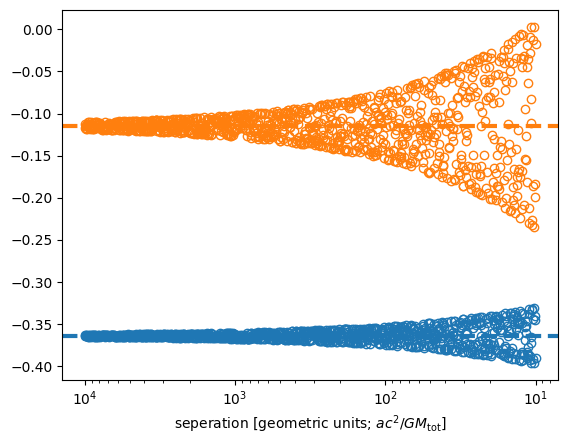

In [115]:
fig, ax = plt.subplots()

ax.axhline(y=jnp.cos(theta1), color='C0', linestyle='--', linewidth=3)
ax.plot(
    out['a'].squeeze(), #a_array,
    jnp.cos(out['theta1'].squeeze()),
    linestyle='',
    markeredgecolor='C0',
    markerfacecolor='none',
    marker='o'
)

ax.axhline(y=jnp.cos(theta2), color='C1', linestyle='--', linewidth=3)
ax.plot(
    out['a'].squeeze(), #a_array,
    jnp.cos(out['theta2'].squeeze()),
    linestyle='',
    markeredgecolor='C1',
    markerfacecolor='none',
    marker='o',
)
ax.set_xscale('log')
plt.gca().invert_xaxis()

ax.set_xlabel(r'seperation [geometric units; $a c^2/ G M_{\rm tot}$]')

Generate spins for everything

In [174]:
from scipy.stats import truncnorm

a_trunc = 0
b_trunc = 1

loc = 0.15
scale = 0.15

a, b = (a_trunc - loc) / scale, (b_trunc - loc) / scale

chi_a = truncnorm.rvs(a, b, loc=loc, scale=scale, size=1_000_000)
chi_b = truncnorm.rvs(a, b, loc=loc, scale=scale, size=1_000_000) 

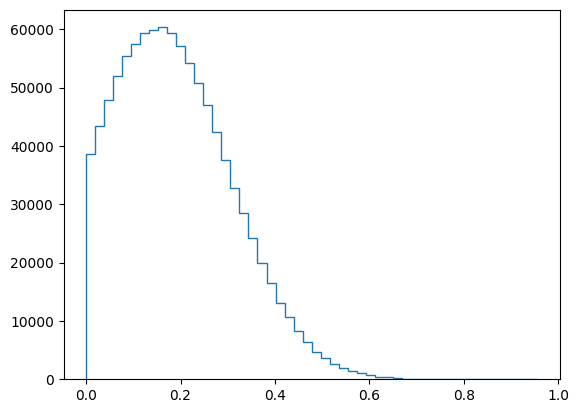

In [175]:
fig, ax = plt.subplots()
ax.hist(chi_a, histtype='step', bins=50);

In [176]:
mask = pops['survive'][-1] & pops['merge'][-1]
indices = np.nonzero(mask)[0]

In [177]:
from astro import speed_of_light
from astro import au_per_meter
from astro import kg_per_msun
from tqdm import tqdm

grav_constant_si = 6.67e-11

outs = []

for i in tqdm(indices):
    ecc_end_evol = pops['ecc_2'][-1][i]

    q_end_evol = pops['mbh_a'][-1][i] / pops['mbh_b'][-1][i]

    deltaphi = pops['phi_a'][-1][i] - pops['phi_b'][-1][i]

    if q_end_evol > 1:
        q_end_evol = 1 / q_end_evol

        theta1 = np.arccos(pops['cos_theta_b_2'][-1][i])
        theta2 = np.arccos(pops['cos_theta_a_2'][-1][i])

        deltaphi *= -1

        chi1 = chi_b[i]
        chi2 = chi_a[i]
    else:
        theta1 = np.arccos(pops['cos_theta_a_2'][-1][i])
        theta2 = np.arccos(pops['cos_theta_b_2'][-1][i])

        chi1 = chi_a[i]
        chi2 = chi_b[i]

    a_array = jnp.logspace(3, 1, 100)

    out = precession.inspiral_precav(
        theta1=theta1,
        theta2=theta2,
        deltaphi=deltaphi,
        a=a_array,
        e=ecc_end_evol,
        q=q_end_evol,
        chi1=chi1,
        chi2=chi2
    )

    outs.append(out)

  0%|          | 0/1206 [00:00<?, ?it/s]

100%|██████████| 1206/1206 [00:36<00:00, 32.74it/s]


In [178]:
cos_theta_1_final = np.cos(np.array([
    outs[i]['theta1'].squeeze()[0]
    for i in range(len(indices))
]))

cos_theta_2_final = np.cos(np.array([
    outs[i]['theta2'].squeeze()[0]
    for i in range(len(indices))
]))

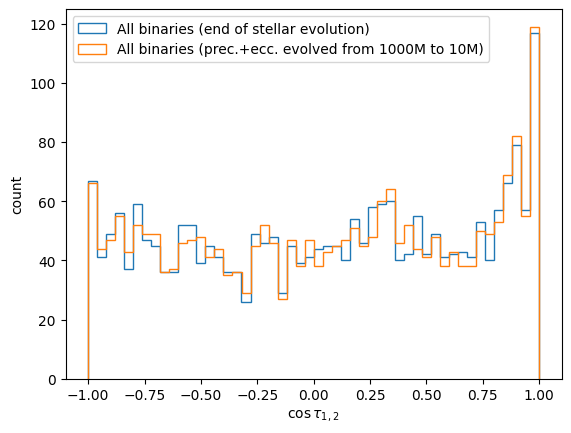

In [183]:
fig, ax = plt.subplots()

ax.hist(
    np.concatenate([
        pops['cos_theta_a_2'][-1][mask],
        pops['cos_theta_b_2'][-1][mask]
    ]),
    histtype='step',
    bins=50,
    label='All binaries (end of stellar evolution)'
);

ax.hist(
    np.concatenate([
        cos_theta_1_final,
        cos_theta_2_final
    ]),
    histtype='step',
    bins=50,
    label='All binaries (prec.+ecc. evolved from 1000M to 10M)'
)

ax.set_xlabel(r'$\cos \tau_{1,2}$')
ax.set_ylabel('count')
ax.legend();
fig.savefig('../../notes/figures/25-12-18/sigma1e3-tau-prec-evol-low-spins.png')

In [184]:
chi_a = np.random.uniform(0, 1, size=1_000_000) #truncnorm.rvs(a, b, loc=loc, scale=scale, size=1_000_000)
chi_b = np.random.uniform(0, 1, size=1_000_000) #truncnorm.rvs(a, b, loc=loc, scale=scale, size=1_000_000) 

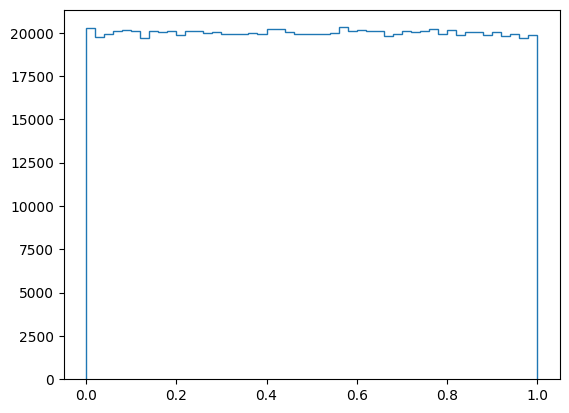

In [185]:
fig, ax = plt.subplots()
ax.hist(chi_a, histtype='step', bins=50);

In [186]:
mask = pops['survive'][-1] & pops['merge'][-1]
indices = np.nonzero(mask)[0]

In [187]:
from astro import speed_of_light
from astro import au_per_meter
from astro import kg_per_msun
from tqdm import tqdm

grav_constant_si = 6.67e-11

outs = []

for i in tqdm(indices):
    ecc_end_evol = pops['ecc_2'][-1][i]

    q_end_evol = pops['mbh_a'][-1][i] / pops['mbh_b'][-1][i]

    deltaphi = pops['phi_a'][-1][i] - pops['phi_b'][-1][i]

    if q_end_evol > 1:
        q_end_evol = 1 / q_end_evol

        theta1 = np.arccos(pops['cos_theta_b_2'][-1][i])
        theta2 = np.arccos(pops['cos_theta_a_2'][-1][i])

        deltaphi *= -1

        chi1 = chi_b[i]
        chi2 = chi_a[i]
    else:
        theta1 = np.arccos(pops['cos_theta_a_2'][-1][i])
        theta2 = np.arccos(pops['cos_theta_b_2'][-1][i])

        chi1 = chi_a[i]
        chi2 = chi_b[i]

    a_array = jnp.logspace(3, 1, 100)

    out = precession.inspiral_precav(
        theta1=theta1,
        theta2=theta2,
        deltaphi=deltaphi,
        a=a_array,
        e=ecc_end_evol,
        q=q_end_evol,
        chi1=chi1,
        chi2=chi2
    )

    outs.append(out)

  0%|          | 0/1206 [00:00<?, ?it/s]

100%|██████████| 1206/1206 [00:43<00:00, 27.49it/s]


In [188]:
cos_theta_1_final = np.cos(np.array([
    outs[i]['theta1'].squeeze()[0]
    for i in range(len(indices))
]))

cos_theta_2_final = np.cos(np.array([
    outs[i]['theta2'].squeeze()[0]
    for i in range(len(indices))
]))

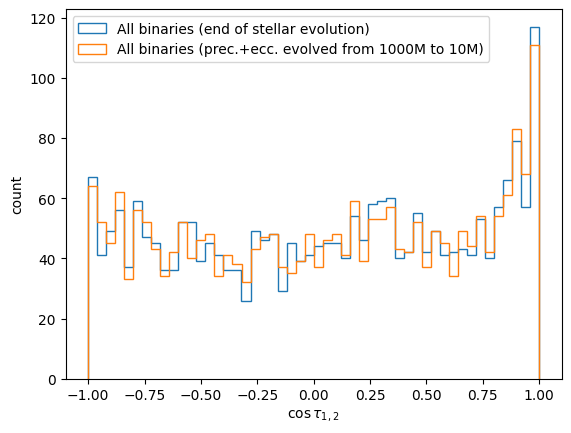

In [189]:
fig, ax = plt.subplots()

ax.hist(
    np.concatenate([
        pops['cos_theta_a_2'][-1][mask],
        pops['cos_theta_b_2'][-1][mask]
    ]),
    histtype='step',
    bins=50,
    label='All binaries (end of stellar evolution)'
)

ax.hist(
    np.concatenate([
        cos_theta_1_final,
        cos_theta_2_final
    ]),
    histtype='step',
    bins=50,
    label='All binaries (prec.+ecc. evolved from 1000M to 10M)'
)

ax.set_xlabel(r'$\cos \tau_{1,2}$')
ax.set_ylabel('count')
ax.legend();
fig.savefig('../../notes/figures/25-12-18/sigma1e3-tau-prec-evol-unif-spins.png')

In [194]:
pops['cos_theta_b_2'][-1][mask][0], pops['cos_theta_a_2'][-1][mask][0]

(Array(-0.36399738, dtype=float64), Array(-0.11441566, dtype=float64))

In [ ]:
cos_theta_1_final[0], cos_theta_2_final[0]

(np.float64(-0.3337716276420596), np.float64(-0.12262824619345786))

: 

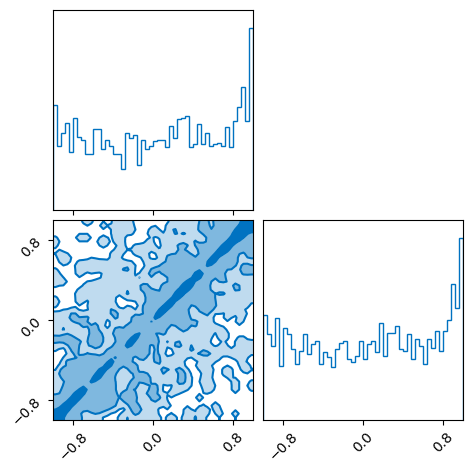

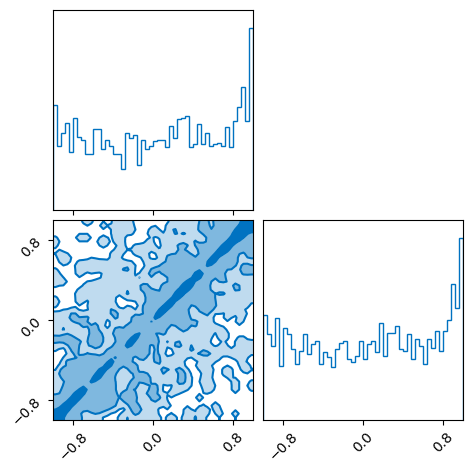

In [ ]:
from util import plot_corner

plot_corner(
    np.column_stack([
        np.concatenate([
            pops['cos_theta_a_2'][-1][mask],
            pops['cos_theta_b_2'][-1][mask]
        ]),
        np.concatenate([
            cos_theta_1_final,
            cos_theta_2_final
        ]),
    ])
)